# Alzheimer's disease diagnosis - classification track

23CSE301 Machine Learning capstone. Dataset is the Alzheimer's Disease dataset from Kaggle (Rabie El Kharoua), `data/alzheimers_disease_data.csv`, which has 2149 patients and 35 columns.

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("sklearn", sklearn.__version__)

pandas 2.3.0
numpy 2.0.2
sklearn 1.7.0


## 3. Data loading

In [2]:
df_raw = pd.read_csv("data/alzheimers_disease_data.csv")
print("shape:", df_raw.shape)
df_raw.head()

shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


Dataset Description

- PatientID - patient id (4751 to 6899), not useful so it gets dropped
- Age - age in years, 60 to 90
- Gender - 0 = Male, 1 = Female
- Ethnicity - 0 = Caucasian, 1 = African American, 2 = Asian, 3 = Other
- EducationLevel - 0 = None, 1 = High School, 2 = Bachelor's, 3 = Higher
- BMI - body mass index, 15 to 40
- Smoking - 0 = No, 1 = Yes
- AlcoholConsumption - units per week, 0 to 20
- PhysicalActivity - hours per week, 0 to 10
- DietQuality - diet score, 0 to 10
- SleepQuality - sleep score, 4 to 10
- FamilyHistoryAlzheimers - family history of Alzheimer's, 0/1
- CardiovascularDisease - 0/1
- Diabetes - 0/1
- Depression - 0/1
- HeadInjury - history of head injury, 0/1
- Hypertension - 0/1
- SystolicBP - systolic blood pressure mmHg, 90 to 180
- DiastolicBP - diastolic blood pressure mmHg, 60 to 120
- CholesterolTotal - total cholesterol mg/dL
- CholesterolLDL - LDL ("bad") cholesterol mg/dL
- CholesterolHDL - HDL ("good") cholesterol mg/dL
- CholesterolTriglycerides - triglycerides mg/dL
- MMSE - Mini Mental State Examination, 0 to 30, lower = more cognitive impairment
- FunctionalAssessment - functional assessment score, 0 to 10, lower = more impairment
- MemoryComplaints - patient complains about memory, 0/1
- BehavioralProblems - 0/1
- ADL - Activities of Daily Living score, 0 to 10, lower = more impairment
- Confusion - 0/1
- Disorientation - 0/1
- PersonalityChanges - 0/1
- DifficultyCompletingTasks - 0/1
- Forgetfulness - 0/1
- Diagnosis - the target. 0 = no Alzheimer's, 1 = Alzheimer's
- DoctorInCharge - supposed to be the doctor, but every row just says "XXXConfid" (confidential), so it gets dropped too

In [3]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "non_null": df_raw.notnull().sum(),
    "missing": df_raw.isnull().sum(),
    "missing_%": round(df_raw.isnull().mean() * 100, 1),
    "n_unique": df_raw.nunique()
})
audit

,dtype,non_null,missing,missing_%,n_unique
PatientID,int64,2149,0,0.0,2149
Age,int64,2149,0,0.0,31
Gender,int64,2149,0,0.0,2
Ethnicity,int64,2149,0,0.0,4
EducationLevel,int64,2149,0,0.0,4
BMI,float64,2149,0,0.0,2149
Smoking,int64,2149,0,0.0,2
AlcoholConsumption,float64,2149,0,0.0,2149
PhysicalActivity,float64,2149,0,0.0,2149
DietQuality,float64,2149,0,0.0,2149


In [4]:
# target distribution
print(df_raw["Diagnosis"].value_counts())
print()
print(df_raw["Diagnosis"].value_counts(normalize=True) * 100)

counts = df_raw["Diagnosis"].value_counts()
print()
print("imbalance ratio 0 : 1 =", round(counts[0] / counts[1], 1), ": 1")
print("majority class baseline accuracy =", round(counts.max() / len(df_raw) * 100, 2), "%")

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

imbalance ratio 0 : 1 = 1.8 : 1
majority class baseline accuracy = 64.63 %


In [5]:
df_raw.drop(columns=["PatientID", "DoctorInCharge"]).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.91,8.99,60.00,67.00,75.00,83.00,90.00
Gender,2149.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00
Ethnicity,2149.0,0.70,1.00,0.00,0.00,0.00,1.00,3.00
EducationLevel,2149.0,1.29,0.90,0.00,1.00,1.00,2.00,3.00
BMI,2149.0,27.66,7.22,15.01,21.61,27.82,33.87,39.99
Smoking,2149.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
AlcoholConsumption,2149.0,10.04,5.76,0.00,5.14,9.93,15.16,19.99
PhysicalActivity,2149.0,4.92,2.86,0.00,2.57,4.77,7.43,9.99
DietQuality,2149.0,4.99,2.91,0.01,2.46,5.08,7.56,10.00
SleepQuality,2149.0,7.05,1.76,4.00,5.48,7.12,8.56,10.00


### audit obervations

2149 patients and 35 columns.

There are only 2 classes for the target feature Diagnosis:

- 0 = no Alzheimer's (1389 patients)
- 1 = Alzheimer's (760 patients)

So this time it's a binary classification, not 3 classes like the cirrhosis one. There is some class imbalance (1.8 : 1) but it's a lot milder, the smaller class is still 35% of the data.

There are no missing values at all, every column has all 2149 values. That's kind of suspicious for real hospital data.

Almost every continuous column has exactly 2149 unique values (BMI, AlcoholConsumption, MMSE, all four cholesterols...), so no two patients share a value, and the min / max are suspiciously neat ranges (BMI 15 to 40, MMSE 0 to 30, FunctionalAssessment and ADL 0 to 10). This makes us think the dataset is synthetic (generated) and not real patient records. We keep this in mind for the rest of the notebook.

DoctorInCharge only has 1 unique value ("XXXConfid") so it can't carry any information. PatientID just counts up from 4751 to 6899.

Most of the columns are stored as int64 even though they're really categories (Gender, Ethnicity and all the yes/no ones), so describe() treats them like numbers. That gets handled in section 7.

Age is already in years this time (60 to 90).

## 4. EDA


### 4.1 Target distribution

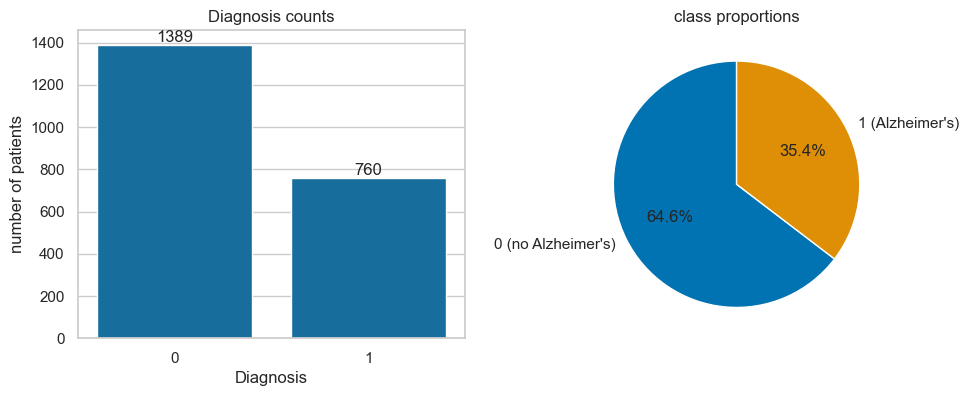

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

order = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="Diagnosis", data=df_raw, order=order, ax=axes[0])
axes[0].set_title("Diagnosis counts")
axes[0].set_ylabel("number of patients")
for c in axes[0].containers:
    axes[0].bar_label(c)

counts = df_raw["Diagnosis"].value_counts()[order]
axes[1].pie(counts, labels=["0 (no Alzheimer's)", "1 (Alzheimer's)"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("class proportions")

plt.show()

Imbalanced but not badly: 0 is 64.6%, 1 is 35.4%. Always predicting "no Alzheimer's" would already get 64.6% accuracy, so that's the number every model has to beat.

### 4.2 Distribution of each numeric feature

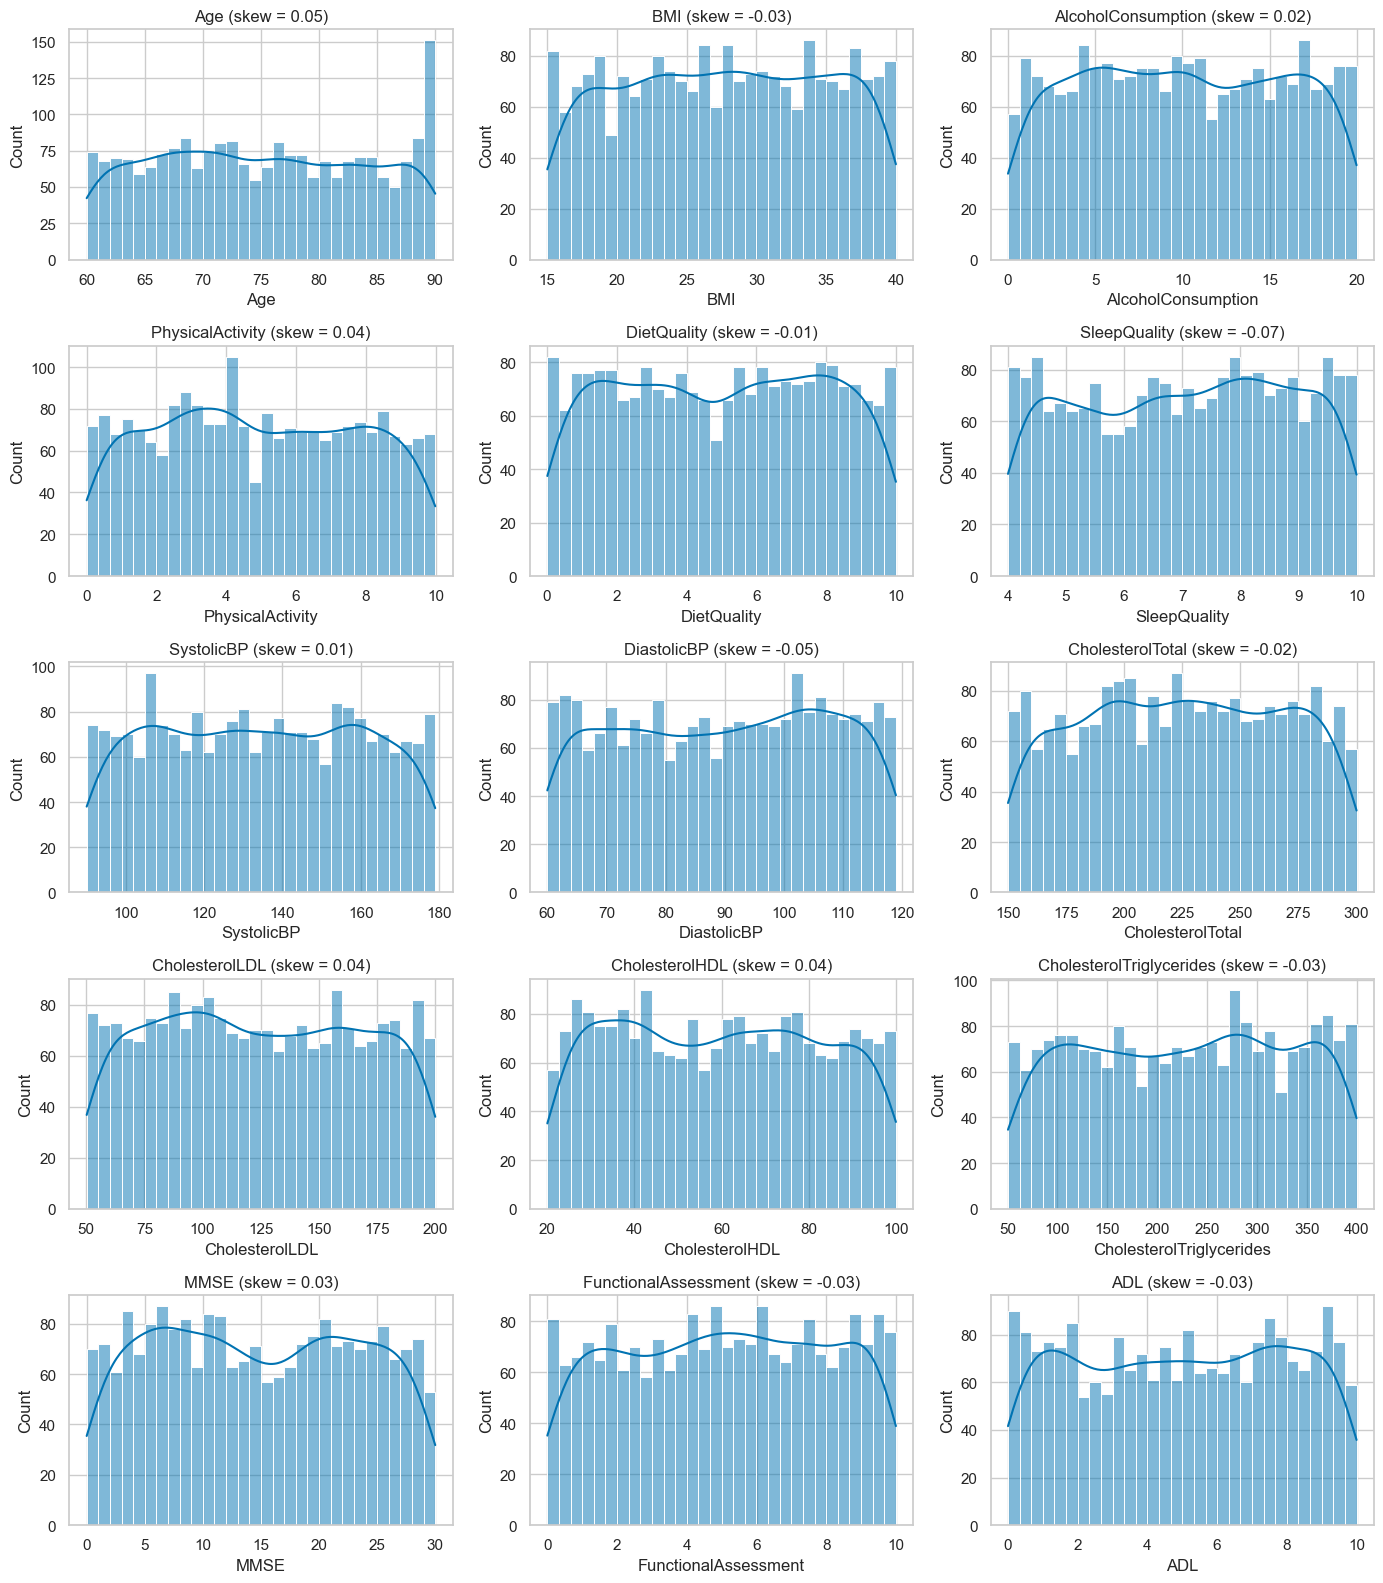

skewness:
Age                         0.05
PhysicalActivity            0.04
CholesterolHDL              0.04
CholesterolLDL              0.04
MMSE                        0.03
AlcoholConsumption          0.02
SystolicBP                  0.01
DietQuality                -0.01
CholesterolTotal           -0.02
BMI                        -0.03
ADL                        -0.03
CholesterolTriglycerides   -0.03
FunctionalAssessment       -0.03
DiastolicBP                -0.05
SleepQuality               -0.07
dtype: float64


In [7]:
# a lot of the columns are 0/1 flags or small codes (ethnicity, education), those aren't really numeric
# so only taking the columns with more than 4 different values
numeric_features = []
for col in df_raw.select_dtypes(include="number").columns:
    if df_raw[col].nunique() > 4 and col != "PatientID":
        numeric_features.append(col)

fig, axes = plt.subplots(5, 3, figsize=(14, 16))
axes = axes.flatten()
for i in range(len(numeric_features)):
    col = numeric_features[i]
    sns.histplot(df_raw[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col + " (skew = " + str(round(df_raw[col].skew(), 2)) + ")")
plt.tight_layout()
plt.show()

print("skewness:")
print(df_raw[numeric_features].skew().sort_values(ascending=False).round(2))

This is the opposite of what we expected. Every numeric feature has a skew between -0.07 and 0.05, so basically zero, and the histograms are flat. They look like uniform distributions, not bell curves and not long tails. Real medical measurements are almost never like this, cholesterol and BMI are usually a bit right skewed, and most people without dementia would score near the top of the MMSE, not spread evenly from 0 to 30. So this is more evidence that each column was generated by sampling uniformly in a range.

The good news is that we don't need any log transforms this time.

### 4.3 How the numeric features separate the two classes

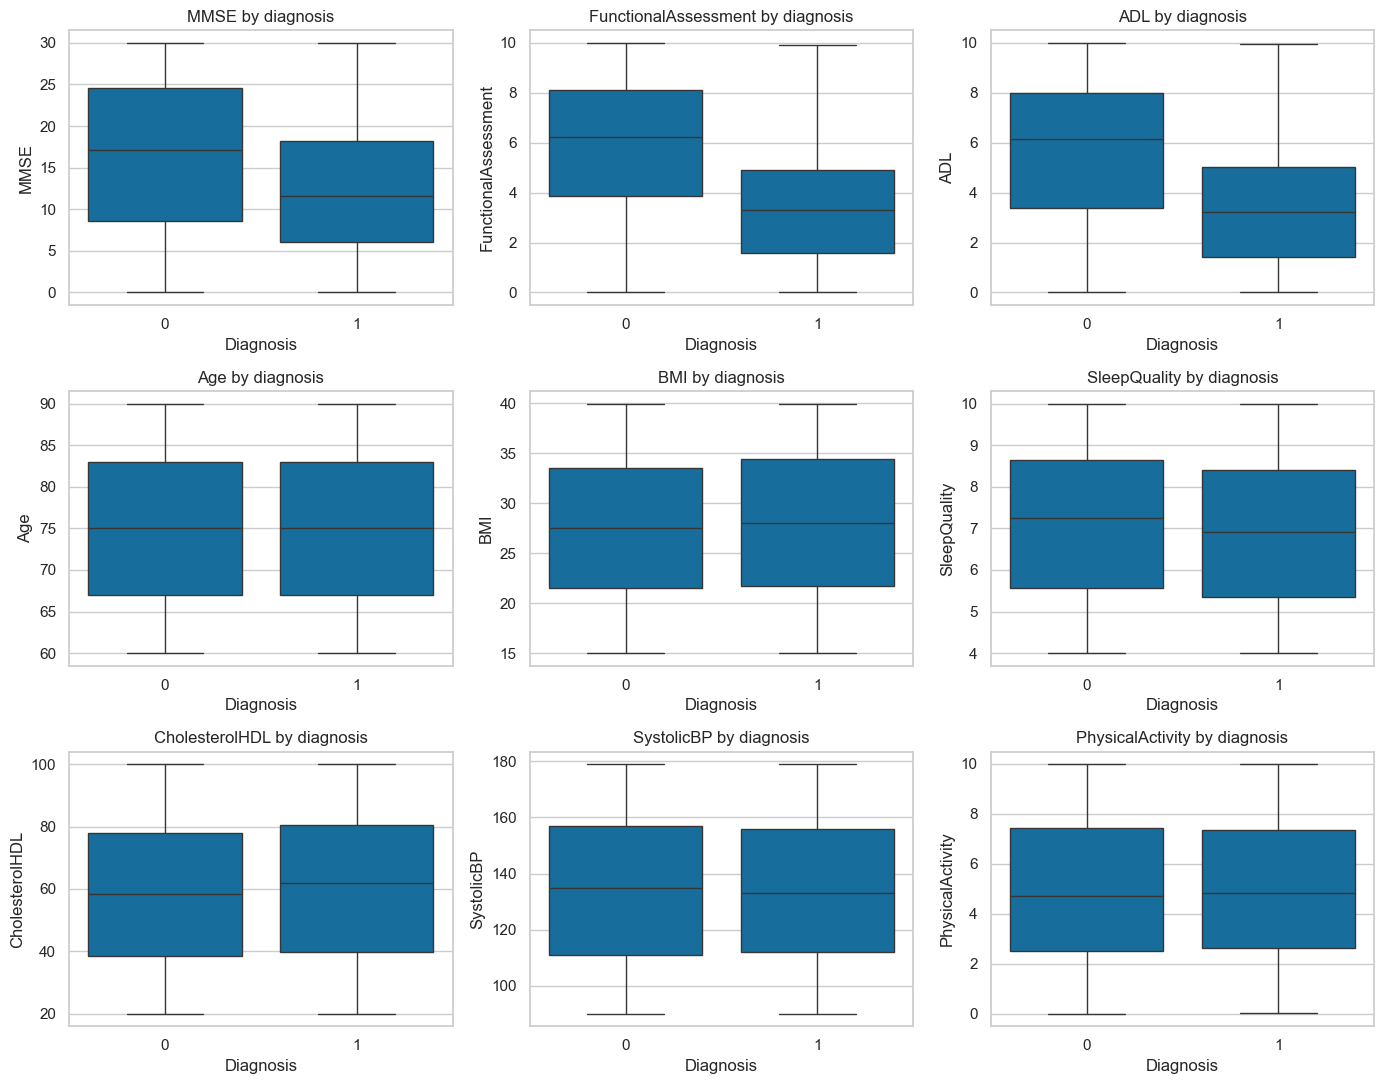

median per class:
            MMSE  FunctionalAssessment   ADL   Age    BMI  SleepQuality  CholesterolHDL  SystolicBP  PhysicalActivity
Diagnosis                                                                                                            
0          17.15                  6.24  6.14  75.0  27.56          7.24           58.30       135.0              4.73
1          11.57                  3.30  3.24  75.0  28.00          6.91           61.85       133.0              4.85


In [8]:
key_features = ["MMSE", "FunctionalAssessment", "ADL", "Age", "BMI", "SleepQuality", "CholesterolHDL", "SystolicBP", "PhysicalActivity"]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
for i in range(len(key_features)):
    col = key_features[i]
    sns.boxplot(x="Diagnosis", y=col, data=df_raw, order=order, ax=axes[i])
    axes[i].set_title(col + " by diagnosis")
    # nothing is skewed in this dataset (4.2) so no log scale needed this time
plt.tight_layout()
plt.show()

print("median per class:")
print(df_raw.groupby("Diagnosis")[key_features].median().round(2))

Only three of these actually separate the classes: MMSE, FunctionalAssessment and ADL. Median MMSE is 17.15 for no Alzheimer's and 11.57 for Alzheimer's, FunctionalAssessment goes from 6.24 to 3.30 and ADL from 6.14 to 3.24. All three go down with Alzheimer's which makes sense, worse cognitive score and less able to do daily things by yourself. FunctionalAssessment and ADL almost halve.

Everything else is basically the same in both groups. Median age is 75.0 in both, which is surprising because age is the biggest known risk factor for Alzheimer's in real life. BMI (27.56 vs 28.00), SleepQuality (7.24 vs 6.91), HDL, blood pressure and physical activity are all within noise.

Even for the three good features the boxes overlap a lot, so no single feature is enough on its own. Also a median MMSE of 17 for the healthy group is weird. In real life a score under 24 already counts as impaired, and here most of the "healthy" patients are under 24.

### 4.4 Scatter plots of features vs target

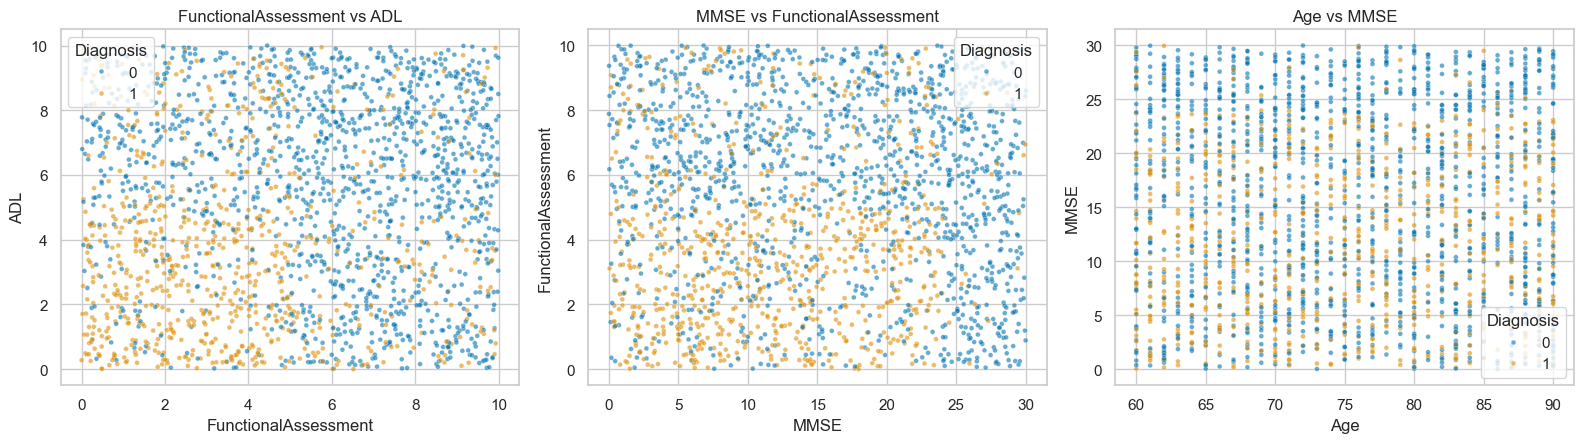

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# 2149 points so making them small and a bit see through
sns.scatterplot(data=df_raw, x="FunctionalAssessment", y="ADL", hue="Diagnosis", hue_order=order, s=12, alpha=0.6, ax=axes[0])
axes[0].set_title("FunctionalAssessment vs ADL")

sns.scatterplot(data=df_raw, x="MMSE", y="FunctionalAssessment", hue="Diagnosis", hue_order=order, s=12, alpha=0.6, ax=axes[1])
axes[1].set_title("MMSE vs FunctionalAssessment")

sns.scatterplot(data=df_raw, x="Age", y="MMSE", hue="Diagnosis", hue_order=order, s=12, alpha=0.6, ax=axes[2])
axes[2].set_title("Age vs MMSE")

plt.tight_layout()
plt.show()

The first plot is probably the most useful 2D view of this dataset. The Alzheimer's patients (orange) are mostly along the bottom and down the left side, so where FunctionalAssessment is below about 5 OR ADL is below about 5. The top right corner, where both are above 5, is almost all blue. So the pattern is an L shape, not a diagonal, and no single straight line can separate it. That's an "either this or that" rule, which a tree can learn with a couple of splits but a linear model can only approximate. So we'd expect the linear models to be ok but the tree models to be better.

There's still a lot of blue inside the L, and a few orange points in the top right corner. Those orange ones are probably the patients who have memory complaints or behavioural problems (4.5) even though their functional scores are fine.

The second plot shows a similar thing with MMSE. Orange is mostly in the bottom half (FunctionalAssessment below 5) and leans towards the left (lower MMSE), but it's much more mixed than the first plot, which fits MMSE having the weakest correlation of the three.

The third one shows no pattern at all. The orange points are spread evenly over every age from 60 to 90 (the vertical stripes are because age is in whole years). That confirms what the boxplots said, age doesn't help in this dataset, even though in real life it's the biggest risk factor.

### 4.5 Categorical features vs the target

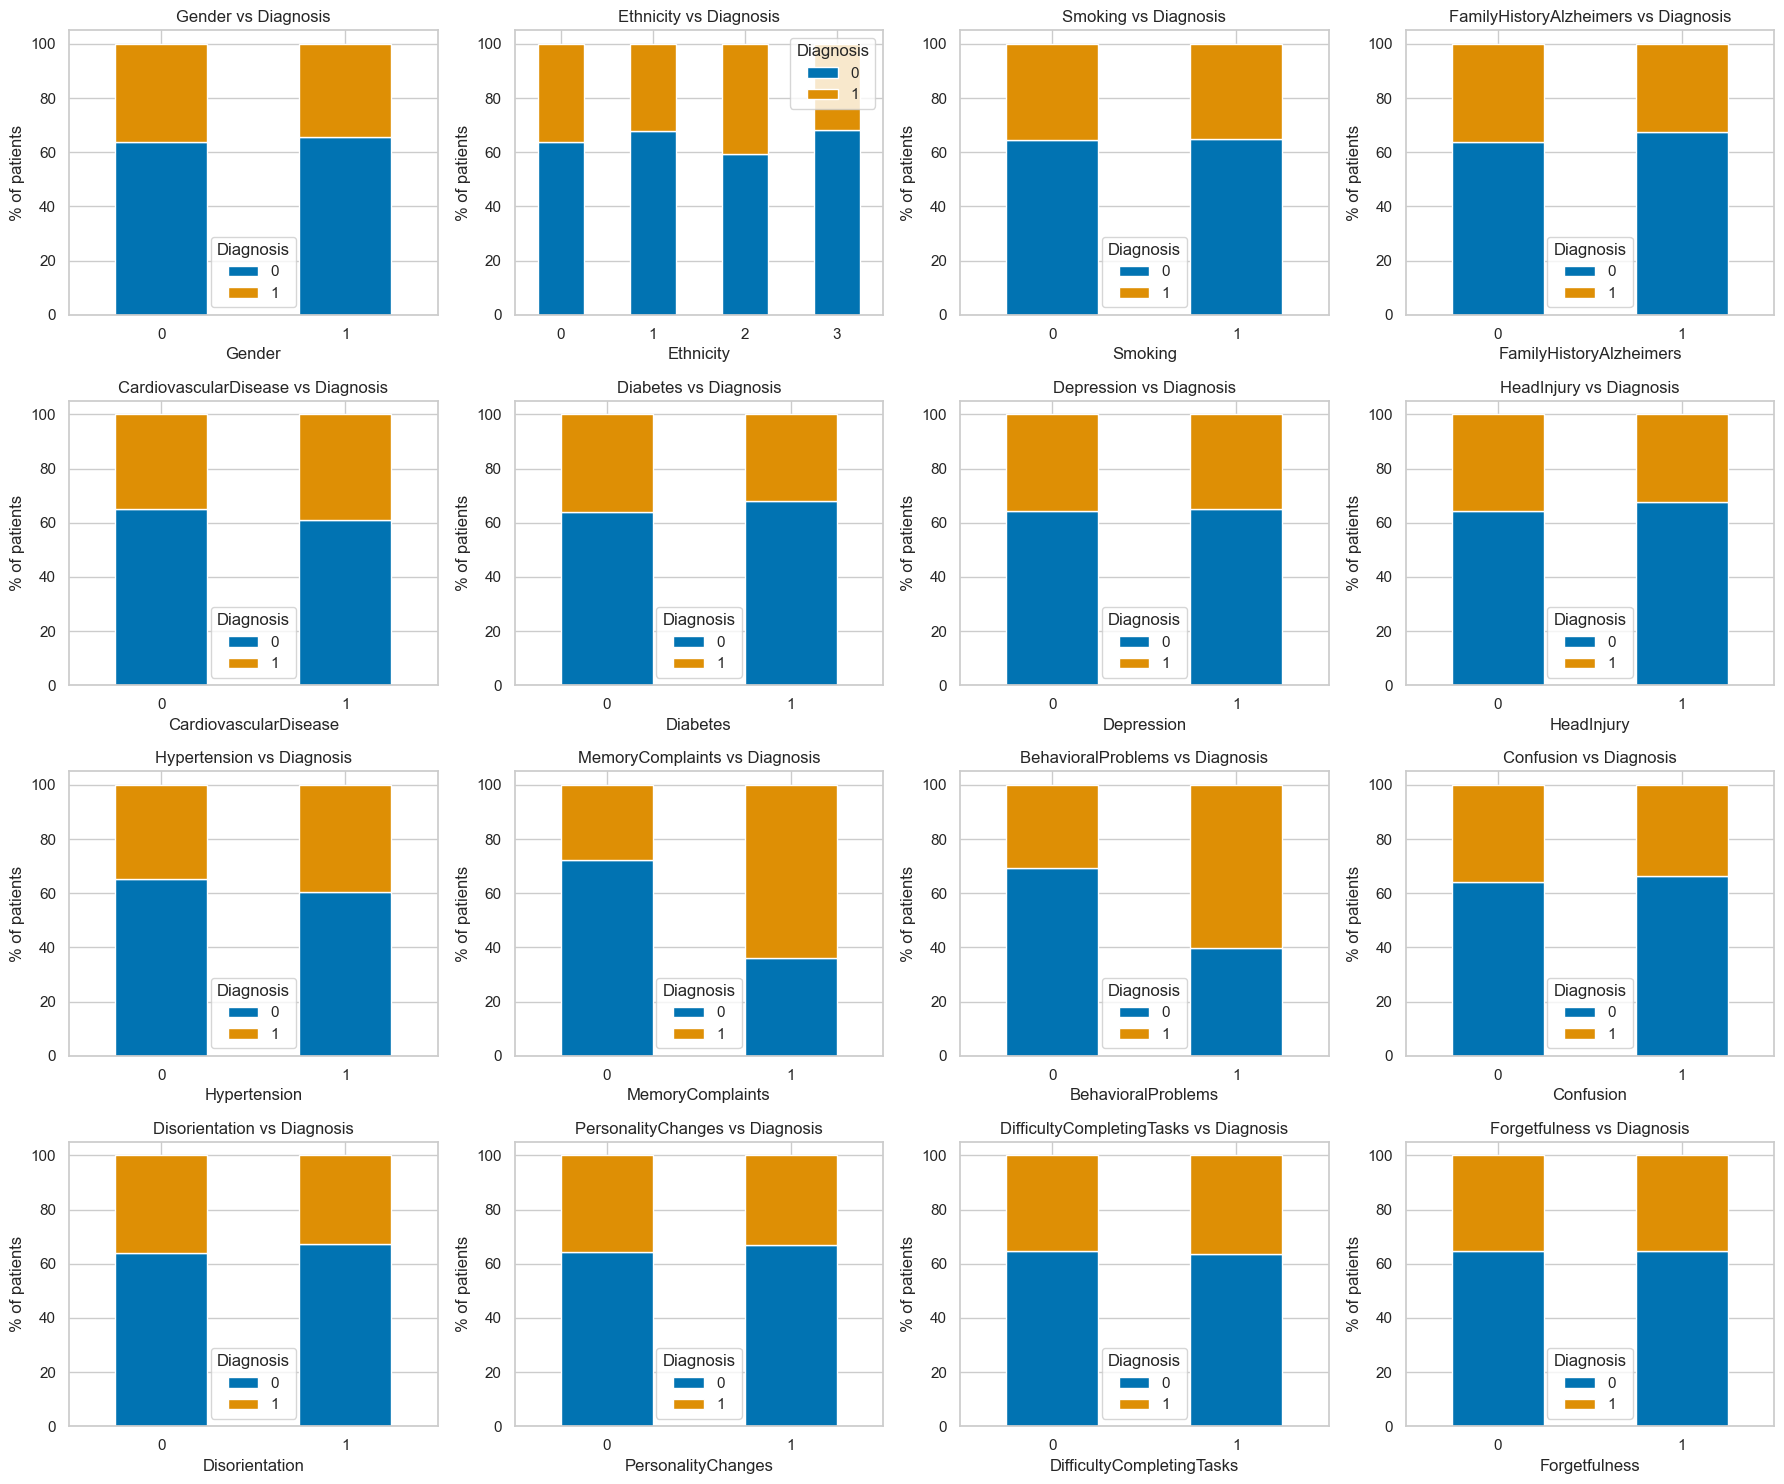

---- Gender ----
Gender
1    1088
0    1061
Name: count, dtype: int64
alzheimer's rate %:
Gender
0    36.4
1    34.4
Name: 1, dtype: float64

---- Ethnicity ----
Ethnicity
0    1278
1     454
3     211
2     206
Name: count, dtype: int64
alzheimer's rate %:
Ethnicity
0    36.2
1    32.2
2    40.8
3    31.8
Name: 1, dtype: float64

---- Smoking ----
Smoking
0    1529
1     620
Name: count, dtype: int64
alzheimer's rate %:
Smoking
0    35.5
1    35.0
Name: 1, dtype: float64

---- FamilyHistoryAlzheimers ----
FamilyHistoryAlzheimers
0    1607
1     542
Name: count, dtype: int64
alzheimer's rate %:
FamilyHistoryAlzheimers
0    36.3
1    32.7
Name: 1, dtype: float64

---- CardiovascularDisease ----
CardiovascularDisease
0    1839
1     310
Name: count, dtype: int64
alzheimer's rate %:
CardiovascularDisease
0    34.7
1    39.0
Name: 1, dtype: float64

---- Diabetes ----
Diabetes
0    1825
1     324
Name: count, dtype: int64
alzheimer's rate %:
Diabetes
0    36.0
1    31.8
Name: 1, dtype: flo

In [10]:
categorical_features = ["Gender", "Ethnicity", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes",
                        "Depression", "HeadInjury", "Hypertension", "MemoryComplaints", "BehavioralProblems",
                        "Confusion", "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"]

fig, axes = plt.subplots(4, 4, figsize=(18, 15))
axes = axes.flatten()
for i in range(len(categorical_features)):
    col = categorical_features[i]
    ct = pd.crosstab(df_raw[col], df_raw["Diagnosis"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(col + " vs Diagnosis")
    axes[i].set_ylabel("% of patients")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

for col in categorical_features:
    print("----", col, "----")
    print(df_raw[col].value_counts())
    print("alzheimer's rate %:")
    print((pd.crosstab(df_raw[col], df_raw["Diagnosis"], normalize="index")[1] * 100).round(1))
    print()

Only two of the sixteen matter: MemoryComplaints and BehavioralProblems. 64.0% of the patients with memory complaints have Alzheimer's vs 27.8% without, and 60.2% of the ones with behavioural problems vs 30.7% without. These are the things a doctor or family member would actually notice, and the tree models will probably split on them early.

Everything else stays within a few percentage points of the 35% base rate:

1. The medical history risk factors barely do anything, and some even go the wrong way. Family history is 32.7% with vs 36.3% without, diabetes 31.8% vs 36.0%, head injury 32.2% vs 35.7%. Hypertension (39.4% vs 34.7%) and cardiovascular disease (39.0% vs 34.7%) go the expected direction but are small. Smoking is 35.0% vs 35.5%.

2. The five symptom columns (Confusion, Disorientation, PersonalityChanges, DifficultyCompletingTasks, Forgetfulness) have no signal at all. Forgetfulness is 35.3% vs 35.4%, which is literally the same. This is really strange clinically because forgetfulness and disorientation are textbook Alzheimer's symptoms. It's another sign the label was generated from only a few columns.

3. Gender (36.4% male vs 34.4% female) and ethnicity (31.8% to 40.8%, but Asian and Other only have about 200 patients each) don't matter much either. In real life women get Alzheimer's more often, we don't see that here.

We still keep all of these columns (it doesn't cost anything) but we expect them near the bottom in feature importance.

### 4.6 Correlation heatmap

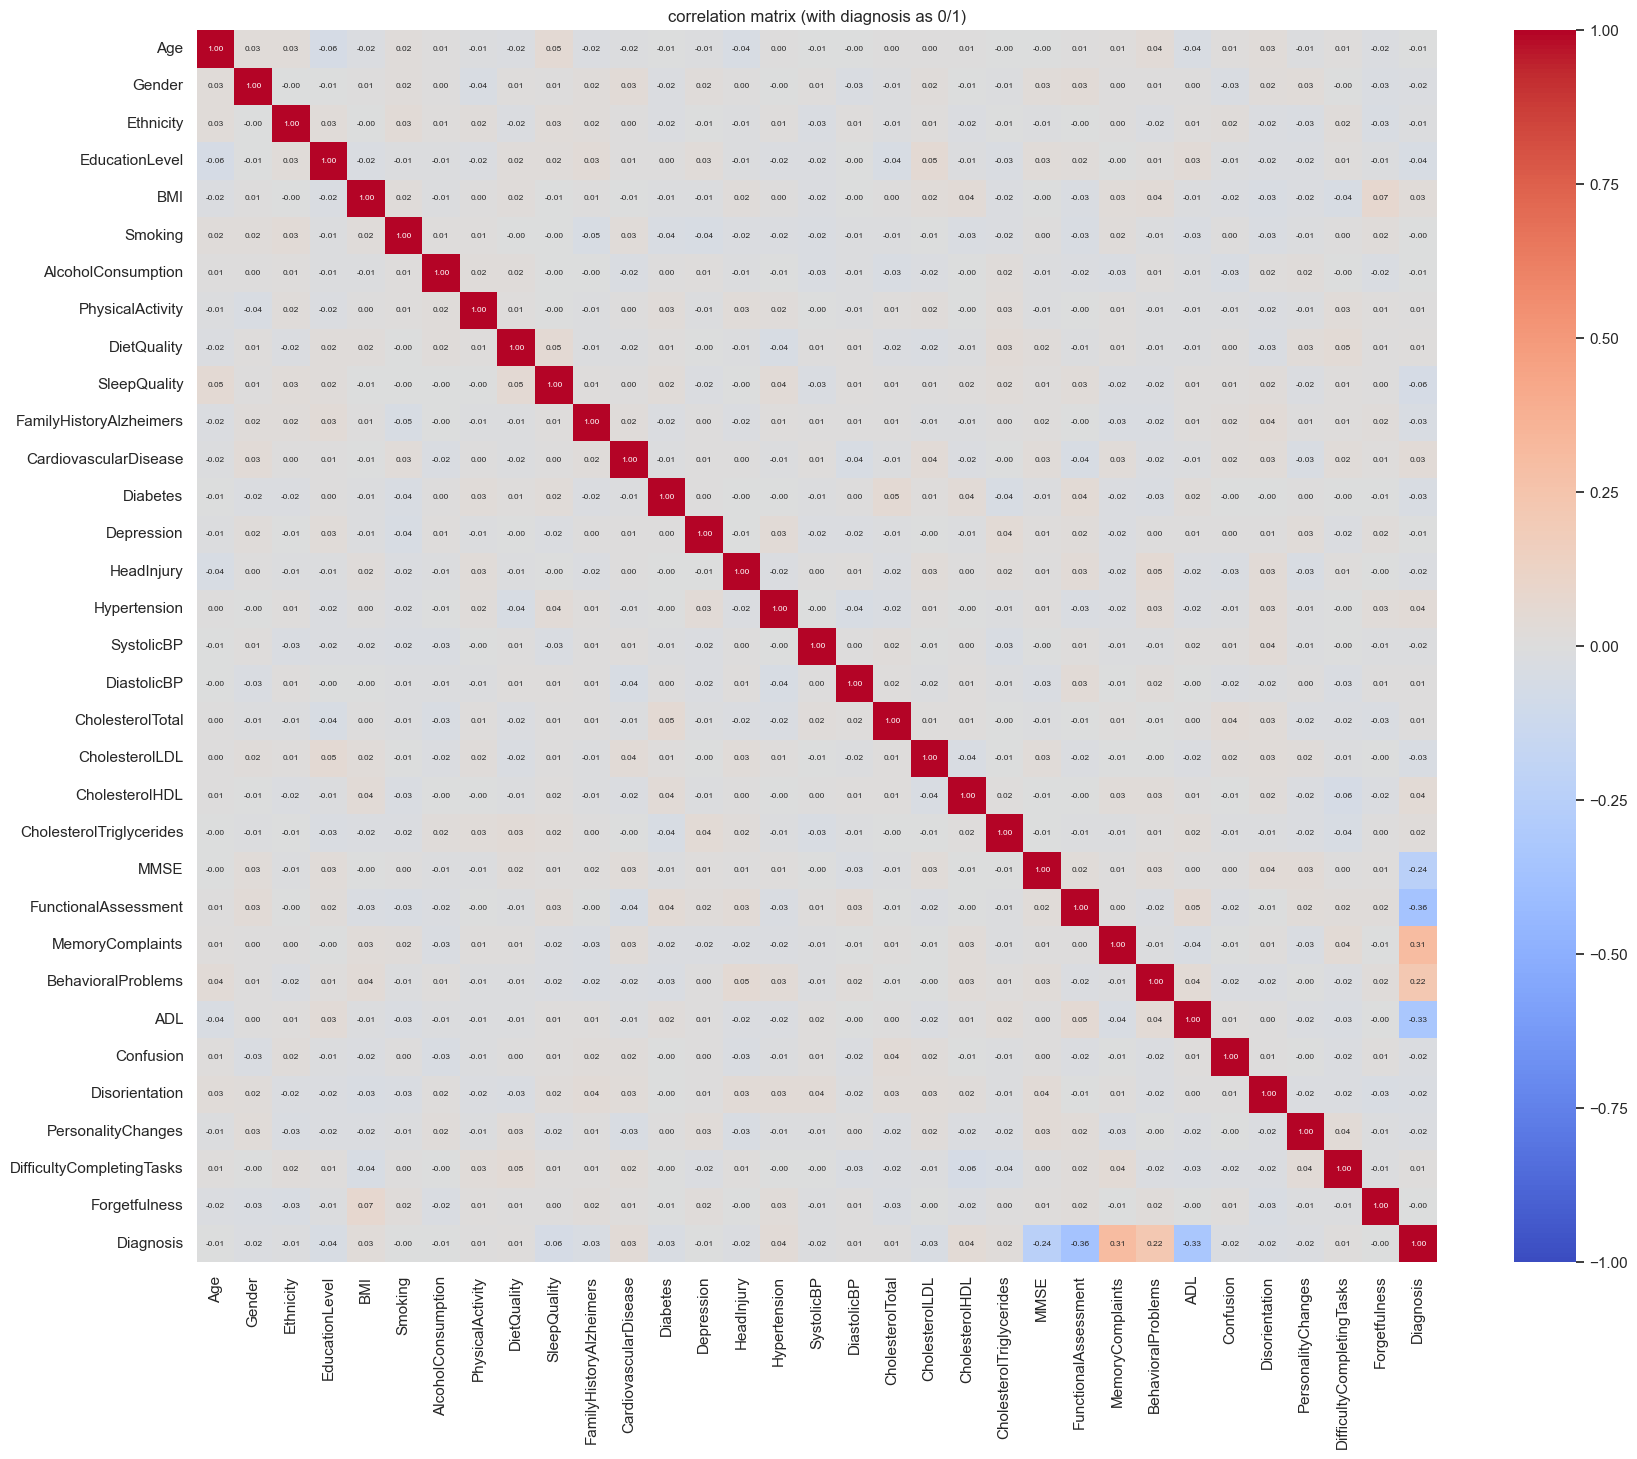

correlation with diagnosis:
MemoryComplaints             0.307
BehavioralProblems           0.224
CholesterolHDL               0.043
Hypertension                 0.035
CardiovascularDisease        0.031
BMI                          0.026
CholesterolTriglycerides     0.023
DifficultyCompletingTasks    0.009
DietQuality                  0.009
CholesterolTotal             0.006
PhysicalActivity             0.006
DiastolicBP                  0.005
Forgetfulness               -0.000
Smoking                     -0.005
Age                         -0.005
Depression                  -0.006
AlcoholConsumption          -0.008
Ethnicity                   -0.015
SystolicBP                  -0.016
Confusion                   -0.019
PersonalityChanges          -0.021
Gender                      -0.021
HeadInjury                  -0.021
Disorientation              -0.025
Diabetes                    -0.032
CholesterolLDL              -0.032
FamilyHistoryAlzheimers     -0.033
EducationLevel             

In [11]:
corr_df = df_raw.drop(columns=["PatientID", "DoctorInCharge"]).select_dtypes(include="number")
# Diagnosis is already 0/1 so it just goes in the heatmap as it is
corr = corr_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, annot_kws={"size": 6})
plt.title("correlation matrix (with diagnosis as 0/1)")
plt.show()

print("correlation with diagnosis:")
print(corr["Diagnosis"].drop("Diagnosis").sort_values(ascending=False).round(3))

Sorted by correlation with diagnosis: FunctionalAssessment (-0.365), ADL (-0.332), MemoryComplaints (+0.307), MMSE (-0.237) and BehavioralProblems (+0.224). After those five there's a huge drop. The next one is SleepQuality (-0.057), and every other feature is between -0.06 and +0.05, which is basically zero. Same five as in 4.3 and 4.5, and they come back again in the feature importances in section 23.

Multicollinearity isn't a problem at all, there basically is none. Apart from the diagonal the whole heatmap is almost white, and the strongest pair between two predictors is only about 0.07.

## 6. Data cleaning

duplicate IDs: 0
duplicate rows (ignoring ID): 0

total missing values: 0
columns with at least one missing value: 0


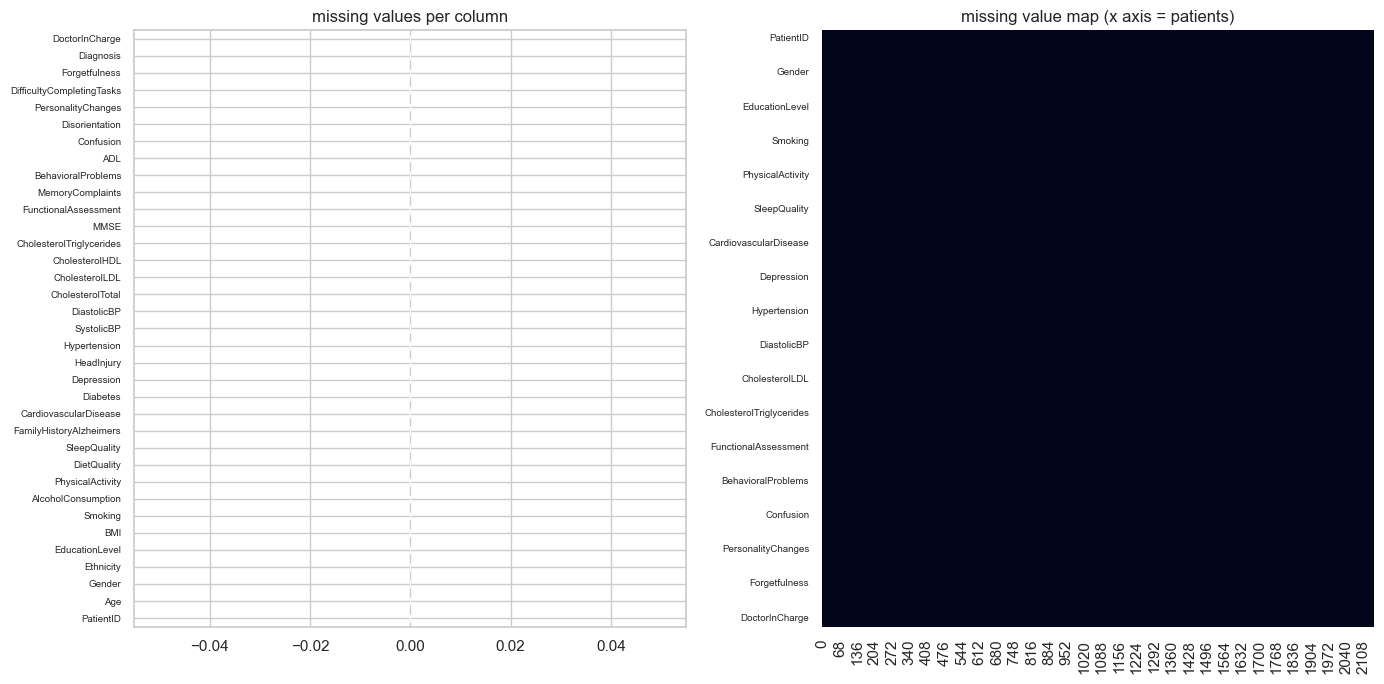

DoctorInCharge value counts:
DoctorInCharge
XXXConfid    2149
Name: count, dtype: int64


In [13]:
# duplicates
print("duplicate IDs:", df_raw["PatientID"].duplicated().sum())
print("duplicate rows (ignoring ID):", df_raw.drop(columns=["PatientID"]).duplicated().sum())

# missing values
missing = df_raw.isnull().sum()
print()
print("total missing values:", missing.sum())
print("columns with at least one missing value:", (missing > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
missing.plot(kind="barh", ax=axes[0])
axes[0].set_title("missing values per column")
axes[0].tick_params(axis="y", labelsize=7)
sns.heatmap(df_raw.isnull().T, cbar=False, ax=axes[1])
axes[1].set_title("missing value map (x axis = patients)")
axes[1].tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

# the doctor column - is it really the same thing in every row?
print("DoctorInCharge value counts:")
print(df_raw["DoctorInCharge"].value_counts())

No duplicates at all, 0 duplicate IDs and 0 duplicate records, so nothing to remove.

No missing values either. The bar chart is all zeros and the missing value map is completely empty, so there's nothing to impute and nothing to delete. We still keep the imputers inside the pipeline (section 8) so that the saved model doesn't crash if a new patient comes in with a gap, it doesn't cost anything.

DoctorInCharge is "XXXConfid" for all 2149 patients, so it's been anonymised and has no information. It gets dropped.

In [14]:
# outliers using the IQR rule
for col in numeric_features:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df_raw[col] < low) | (df_raw[col] > high)).sum()
    pct = round(100 * n_out / df_raw[col].notnull().sum(), 1)
    print(col, ":", n_out, "outliers (", pct, "% )   fences:", round(low, 2), "to", round(high, 2), "  max:", df_raw[col].max())

Age : 0 outliers ( 0.0 % )   fences: 43.0 to 107.0   max: 90
BMI : 0 outliers ( 0.0 % )   fences: 3.22 to 52.26   max: 39.99276746402374
AlcoholConsumption : 0 outliers ( 0.0 % )   fences: -9.89 to 30.19   max: 19.98929335906197
PhysicalActivity : 0 outliers ( 0.0 % )   fences: -4.72 to 14.71   max: 9.987429413422252
DietQuality : 0 outliers ( 0.0 % )   fences: -5.19 to 15.21   max: 9.99834567881401
SleepQuality : 0 outliers ( 0.0 % )   fences: 0.86 to 13.18   max: 9.99984031668144
SystolicBP : 0 outliers ( 0.0 % )   fences: 44.5 to 224.5   max: 179
DiastolicBP : 0 outliers ( 0.0 % )   fences: 27.5 to 151.5   max: 119
CholesterolTotal : 0 outliers ( 0.0 % )   fences: 82.58 to 369.7   max: 299.99335247432657
CholesterolLDL : 0 outliers ( 0.0 % )   fences: -24.61 to 273.54   max: 199.96566510142804
CholesterolHDL : 0 outliers ( 0.0 % )   fences: -20.67 to 138.7   max: 99.98032407804152
CholesterolTriglycerides : 0 outliers ( 0.0 % )   fences: -128.3 to 580.72   max: 399.9418615941332
MMS

0 outliers in every single numeric column. The IQR fences are way outside the actual range of the data, for example MMSE's fences are -15.32 to 44.65 but the scores only go from 0 to 30.

That's what happens with uniform distributions: they have no tails, so nothing is ever far from the middle. In the cirrhosis data we had to decide what to do with extreme patients, here there's nothing to handle, no clipping and no log transforms. (Honestly it's one more sign the data is synthetic, real clinical values basically always have some outliers.)

## 7. Feature engineering


In [15]:
def engineer_features(frame):
    out = frame.copy()

    # 1. MMSE below 24 is the usual clinical cutoff for "cognitive impairment"
    # gives the models the cutoff doctors actually use instead of making them find it
    out["MMSE_Impaired"] = (out["MMSE"] < 24).astype(int)

    # 2. cognitive + functional index, all three assessments put on a 0-1 scale and added (0 to 3, lower = worse)
    # MMSE is out of 30, FunctionalAssessment and ADL are out of 10
    # a bit like a combined severity score, one number instead of three
    out["Cog_Func_Index"] = out["MMSE"] / 30 + out["FunctionalAssessment"] / 10 + out["ADL"] / 10

    # 3. clinical flags - memory complaints + behavioural problems (0 to 2)
    # these are the two yes/no things a doctor would notice in the appointment
    out["Clinical_Flags"] = out["MemoryComplaints"] + out["BehavioralProblems"]

    # 4. symptom count - how many of the 5 cognitive symptoms the patient has (0 to 5)
    # lets a linear model use "more symptoms = more likely" without interaction terms
    out["Symptom_Count"] = (out["Confusion"] + out["Disorientation"] + out["PersonalityChanges"]
                            + out["DifficultyCompletingTasks"] + out["Forgetfulness"])

    # 5. risk factor count - how many of the known risk factors from the medical history (0 to 7)
    out["Risk_Factor_Count"] = (out["FamilyHistoryAlzheimers"] + out["CardiovascularDisease"] + out["Diabetes"]
                                + out["Depression"] + out["HeadInjury"] + out["Hypertension"] + out["Smoking"])

    # no log transforms this time, nothing is skewed (section 6)

    # turning the 0/1 codes into labels so the one hot encoder treats them as categories and not numbers
    # (ethnicity 0-3 isn't in any order, "Asian" isn't 2x "African American")
    out["Gender"] = out["Gender"].map({0: "Male", 1: "Female"})
    out["Ethnicity"] = out["Ethnicity"].map({0: "Caucasian", 1: "African_American", 2: "Asian", 3: "Other"})
    for col in ["Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes", "Depression",
                "HeadInjury", "Hypertension", "MemoryComplaints", "BehavioralProblems", "Confusion",
                "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"]:
        out[col] = out[col].map({0: "N", 1: "Y"})

    return out


df = engineer_features(df_raw)

engineered = ["MMSE_Impaired", "Cog_Func_Index", "Clinical_Flags", "Symptom_Count", "Risk_Factor_Count"]
df[engineered].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
MMSE_Impaired,2149.0,0.807,0.395,0.000,1.000,1.000,1.000,1.000
Cog_Func_Index,2149.0,1.498,0.517,0.135,1.137,1.516,1.859,2.871
Clinical_Flags,2149.0,0.365,0.542,0.000,0.000,0.000,1.000,2.000
Symptom_Count,2149.0,0.974,0.864,0.000,0.000,1.000,1.000,4.000
Risk_Factor_Count,2149.0,1.278,0.985,0.000,1.000,1.000,2.000,6.000


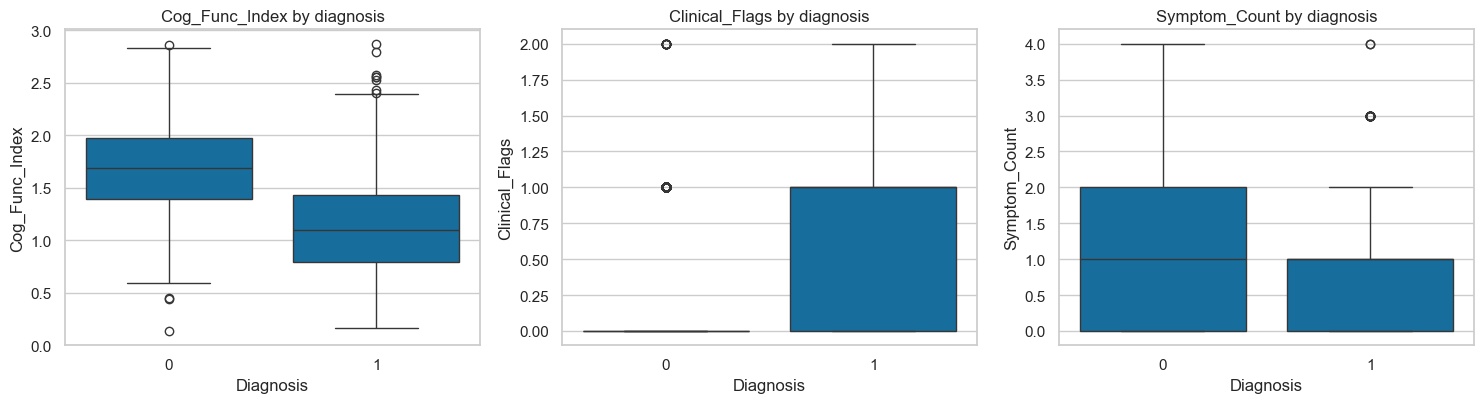

correlation with diagnosis:
raw features
   FunctionalAssessment -0.365
   ADL -0.332
   MMSE -0.237
   MemoryComplaints 0.307
   BehavioralProblems 0.224
engineered features
   Cog_Func_Index -0.526
   Clinical_Flags 0.38
   MMSE_Impaired 0.313
   Symptom_Count -0.024
   Risk_Factor_Count -0.013


In [16]:
# checking if the new features actually separate the classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
new_cols = ["Cog_Func_Index", "Clinical_Flags", "Symptom_Count"]
for i in range(3):
    sns.boxplot(x="Diagnosis", y=new_cols[i], data=df, order=order, ax=axes[i])
    axes[i].set_title(new_cols[i] + " by diagnosis")
plt.tight_layout()
plt.show()

diagnosis = df["Diagnosis"]
print("correlation with diagnosis:")
print("raw features")
# using df_raw here because in df the yes/no columns are now text
for col in ["FunctionalAssessment", "ADL", "MMSE", "MemoryComplaints", "BehavioralProblems"]:
    print("  ", col, round(df_raw[col].corr(diagnosis), 3))
print("engineered features")
for col in ["Cog_Func_Index", "Clinical_Flags", "MMSE_Impaired", "Symptom_Count", "Risk_Factor_Count"]:
    print("  ", col, round(df[col].corr(diagnosis), 3))

So three of the engineered features help a lot and two of them do nothing.

Cog_Func_Index is now the strongest feature in the whole dataset (-0.526), way stronger than any of the three scores it's made from (FunctionalAssessment -0.365, ADL -0.332, MMSE -0.237). Because the three scores are independent of each other (4.6), adding them together averages out a lot of the noise in each one. Clinical_Flags (0.380) beats MemoryComplaints (0.307) and BehavioralProblems (0.224) on their own for the same reason. The boxplots show it too: median Cog_Func_Index is 1.69 for no Alzheimer's vs 1.10 for Alzheimer's, and median Clinical_Flags goes from 0 to 1.

MMSE_Impaired (0.313) beats raw MMSE (-0.237) even though it throws information away by turning it into yes/no. The cutoff doesn't work the way it would in real life though, since most of the healthy patients are under 24 too (4.3).

Symptom_Count (-0.024) and Risk_Factor_Count (-0.013) are basically zero, because the columns they're built from have no signal (4.5) and adding up zeros gives zero. The Symptom_Count boxplot looks the same for both classes. We keep them in anyway because they're what you'd use clinically, and it's an honest result that they don't help on this data.

## 8. Feature selection, train/test split, preprocessing pipeline

Rubric B2: proper encoding for categoricals, the right scaler (fit on training data only), and a stratified split.

In [17]:
# final feature list
# dropped: PatientID (just an index) and DoctorInCharge (same value in every row), see section 5
# all the raw columns are kept this time, the engineered ones are added on top
# (there were no log versions to swap in like you'd do with skewed data)
NUMERIC_COLS = ["Age", "EducationLevel", "BMI", "AlcoholConsumption", "PhysicalActivity", "DietQuality",
                "SleepQuality", "SystolicBP", "DiastolicBP", "CholesterolTotal", "CholesterolLDL",
                "CholesterolHDL", "CholesterolTriglycerides", "MMSE", "FunctionalAssessment", "ADL",
                "MMSE_Impaired", "Cog_Func_Index", "Clinical_Flags", "Symptom_Count", "Risk_Factor_Count"]
CATEGORICAL_COLS = ["Gender", "Ethnicity", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
                    "Diabetes", "Depression", "HeadInjury", "Hypertension", "MemoryComplaints",
                    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
                    "DifficultyCompletingTasks", "Forgetfulness"]

X = df[NUMERIC_COLS + CATEGORICAL_COLS]
y = df["Diagnosis"]

print("X shape:", X.shape, "-", len(NUMERIC_COLS), "numeric,", len(CATEGORICAL_COLS), "categorical")
print("classes:", sorted(y.unique()))

X shape: (2149, 37) - 21 numeric, 16 categorical
classes: [np.int64(0), np.int64(1)]


In [18]:
# stratify=y so both sets keep the same 65/35 class mix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("train:", X_train.shape[0], "patients")
print("test:", X_test.shape[0], "patients")
print()
print("train class counts:")
print(y_train.value_counts())
print()
print("test class counts:")
print(y_test.value_counts())

train: 1719 patients
test: 430 patients

train class counts:
Diagnosis
0    1111
1     608
Name: count, dtype: int64

test class counts:
Diagnosis
0    278
1    152
Name: count, dtype: int64


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# numeric: median impute then scale
# there are no missing values in this dataset, but the imputer stays in so the saved model doesn't crash on a new patient with a gap
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical: missing becomes its own category (same reason as above) then one hot
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Not_recorded")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_COLS),
    ("cat", categorical_pipeline, CATEGORICAL_COLS)
])

# fitting once here only to see the feature names after one hot encoding
# every model gets its own fresh copy inside its pipeline later
preprocessor.fit(X_train)
FEATURE_NAMES = []
for name in preprocessor.get_feature_names_out():
    FEATURE_NAMES.append(name.split("__")[1])

print(len(FEATURE_NAMES), "features after encoding:")
print(FEATURE_NAMES)

40 features after encoding:
['Age', 'EducationLevel', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL', 'MMSE_Impaired', 'Cog_Func_Index', 'Clinical_Flags', 'Symptom_Count', 'Risk_Factor_Count', 'Gender_Male', 'Ethnicity_African_American', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Other', 'Smoking_Y', 'FamilyHistoryAlzheimers_Y', 'CardiovascularDisease_Y', 'Diabetes_Y', 'Depression_Y', 'HeadInjury_Y', 'Hypertension_Y', 'MemoryComplaints_Y', 'BehavioralProblems_Y', 'Confusion_Y', 'Disorientation_Y', 'PersonalityChanges_Y', 'DifficultyCompletingTasks_Y', 'Forgetfulness_Y']
